In [1]:
from modules.QCS import Gate, Functions, torch
from modules.Reinforcementlearning import SemiGradSarsa, Tile, torch, nn, random, plt, clear_output
from time import sleep
import ipywidgets

In [2]:
class ActionGates:

    def __init__(self, N_qbits, singlegates_config = "X Y Z H",
                                doublegates_config = "CX CZ",
                                meassuregates_config = "MX MZ"):
        
        self.N_qbits = N_qbits
        targets = list(range(self.N_qbits))
        singlegate_targets = []
        for i in targets:
            if i != 0:
                singlegate_targets.append([i])
        
        doublegate_targets = []
        for i in targets:
            for j in targets:
                if abs(i-j)==1 and i != 0 and j != 0:
                    doublegate_targets.append([i,j])
        
        meassuregate_targets = []
        for i in targets:
            for j in targets:
                if abs(i-j)!=0:
                    meassuregate_targets.append([i,j])
        
        print(f"allowed single gates: {singlegates_config}")
        print(f"possible single targets: {singlegate_targets}")
        print(f"allowed double gates: {doublegates_config}")
        print(f"possible double control/target pairs: {doublegate_targets}")
        print(f"allowed measure gates: {meassuregates_config}")
        print(f"possible meassure meassure targets: {meassuregate_targets}")
        
        self.actions = []
        
        for gate in singlegates_config.split():
            for target in singlegate_targets:
                self.actions.append(Gate(gate, target))
        for gate in doublegates_config.split():
            for target in doublegate_targets:
                self.actions.append(Gate(gate, target))
        for gate in meassuregates_config.split():
            for target in meassuregate_targets:
                self.actions.append(Gate(gate, target))
        print(f"{len(self.actions)} actions in total")

        random_state = Functions.random_state(self.N_qbits)

        try:
            for action in self.actions:
                check = action(random_state)
            print("every actions works!")
        except:
            print(f"{action} does not work!")

    def __getitem__(self, key):
        return self.actions[key]

    def __iter__(self):
        for action in self.actions:
            yield action

    def __str__(self):
        string = ""
        for i, action in enumerate(self.actions):
            if len(str(action)) < 10:
                string += f"{action} \t\t index: {i}\n"
            else:
                string += f"{action} \t index: {i}\n"
        return string

    def __len__(self):
        return len(self.actions)

In [3]:
class ActionEnviroment:
    def __init__(self, actions, max_steps, difficulty=4):
        sol_index = 6 - difficulty
        full_solution = [Gate("H", [1]), Gate("CX", [1,0]),
                 Gate("CX", [2, 1]), Gate("H", [2]),
                 Gate("MX", [1,0]), Gate("MZ", [2,0])]

        self.start = full_solution[:sol_index]
        self.solution = full_solution[sol_index:]
        
        self.random_state = Functions.random_state()
        self.actions = actions
        self.max_steps = max_steps

    def test_solution(self):
        state = self.setup()[0]
        for gate in self.solution:
            state = gate(state)
        if self.terminal_check(state):
            print("Solution good!")
        else:
            print("Solution bad!")

    def test_net(self, qnet):
        try:
            S = env.setup()
            goal_reached = False
            for i in range(self.max_steps):
                q_values = qnet(S)
                if torch.std(q_values) == 0:
                    A = random.randint(0, len(self.actions)-1)
                else:
                    A = torch.argmax(q_values)
                S, R, goal_reached = self.step(S, A)
                print(self.actions[A])
                sleep(0.5)
                if goal_reached:
                    print(f"\nGoal in {i+1} steps!")
                    break
            if not goal_reached:
                print(f"\nFailed in {i+1} steps!")                    
        except KeyboardInterrupt:
            clear_output()
        
    def terminal_check(self, state):
        p = torch.tensordot(torch.conj(state), state, dims=[[1,2],[1,2]])
        q = torch.conj(self.random_state).unsqueeze(-1) * self.random_state.unsqueeze(0)
        trace = torch.sum(p * q.T)
        return torch.abs(trace - 1) < 1e-6
    
    def setup(self):
        self.random_state = Functions.random_state()
        state = Functions.combine(Functions.classic_state([0,0], as_list=True) + [self.random_state])
        for gate in self.start:
            state = gate(state)
        action_log = [-1 for _ in range(self.max_steps)]
        return (state, action_log)

    def step(self, action_state, action):
        new_state = self.actions[action](action_state[0])
        new_action_log = action_state[1] * 1
        for i in range(self.max_steps):
            if new_action_log[i] == -1:
                new_action_log[i] = action
                break
        return (new_state, new_action_log), -1, self.terminal_check(new_state)

In [4]:
class ActionModel(nn.Module):
    def __init__(self, max_steps, N_actions):
        super(ActionModel, self).__init__()
        self.w = nn.Parameter(torch.zeros(max_steps, N_actions+1, N_actions, requires_grad=True))
        self.max_steps = max_steps
        self.N_actions = N_actions
        
    def forward(self, action_state):
        action_log = action_state[1]
        out = torch.zeros(self.N_actions)
        if len(action_log) == 0:
            out += self.start
        for i, index in enumerate(action_log):
            out += self.w[i, index]
        return out

In [5]:
N_qbits = 3
actions = ActionGates(N_qbits, singlegates_config = "H",
                               doublegates_config = "CX",
                               meassuregates_config = "MX MZ")

max_steps=6

print("\n" + str(actions))

env = ActionEnviroment(actions, max_steps, difficulty=4)
env.test_solution()

allowed single gates: H
possible single targets: [[1], [2]]
allowed double gates: CX
possible double control/target pairs: [[1, 2], [2, 1]]
allowed measure gates: MX MZ
possible meassure meassure targets: [[0, 1], [0, 2], [1, 0], [1, 2], [2, 0], [2, 1]]
16 actions in total
every actions works!

H->[1] 		 index: 0
H->[2] 		 index: 1
C[1]->X[2] 	 index: 2
C[2]->X[1] 	 index: 3
M[0]->X[1] 	 index: 4
M[0]->X[2] 	 index: 5
M[1]->X[0] 	 index: 6
M[1]->X[2] 	 index: 7
M[2]->X[0] 	 index: 8
M[2]->X[1] 	 index: 9
M[0]->Z[1] 	 index: 10
M[0]->Z[2] 	 index: 11
M[1]->Z[0] 	 index: 12
M[1]->Z[2] 	 index: 13
M[2]->Z[0] 	 index: 14
M[2]->Z[1] 	 index: 15

Solution good!


In [6]:
net = ActionModel(max_steps, N_actions=len(actions))

In [7]:
S = env.setup()
S, R, goal_reached = env.step(S, 0)
S, R, goal_reached = env.step(S, 3)
print(goal_reached)

tensor(False)


In [8]:
sarsa = SemiGradSarsa(env, net, max_steps=max_steps)

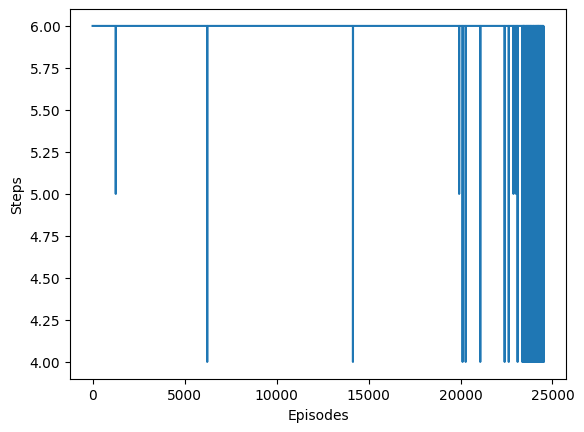

In [13]:
sarsa.run(max_episode=10000)

In [14]:
env.test_net(net)

C[2]->X[1]
H->[2]
M[2]->Z[0]
M[1]->X[0]

Goal in 4 steps!


In [11]:
S = env.setup()
for i in range(max_steps):
    q = net(S)
    print(f"q-values in step {i+1}: {q}")
    a = torch.argmax(q)


q-values in step 1: tensor([-5.5607, -5.6478, -5.5843, -5.5522, -5.5681, -5.5635, -5.4562, -5.6734,
        -5.5551, -5.5673, -5.5548, -5.5699, -5.4731, -5.5535, -5.4929, -5.5107],
       grad_fn=<AddBackward0>)
q-values in step 2: tensor([-5.5607, -5.6478, -5.5843, -5.5522, -5.5681, -5.5635, -5.4562, -5.6734,
        -5.5551, -5.5673, -5.5548, -5.5699, -5.4731, -5.5535, -5.4929, -5.5107],
       grad_fn=<AddBackward0>)
q-values in step 3: tensor([-5.5607, -5.6478, -5.5843, -5.5522, -5.5681, -5.5635, -5.4562, -5.6734,
        -5.5551, -5.5673, -5.5548, -5.5699, -5.4731, -5.5535, -5.4929, -5.5107],
       grad_fn=<AddBackward0>)
q-values in step 4: tensor([-5.5607, -5.6478, -5.5843, -5.5522, -5.5681, -5.5635, -5.4562, -5.6734,
        -5.5551, -5.5673, -5.5548, -5.5699, -5.4731, -5.5535, -5.4929, -5.5107],
       grad_fn=<AddBackward0>)
q-values in step 5: tensor([-5.5607, -5.6478, -5.5843, -5.5522, -5.5681, -5.5635, -5.4562, -5.6734,
        -5.5551, -5.5673, -5.5548, -5.5699, -5.4731,